<a href="https://colab.research.google.com/github/dougyd92/ML-Foudations/blob/main/Notebooks/12_Classical_ML_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 12: Classical ML Review & Capstone Project Workshop

**⚠️ Important: Go to File → Save a copy in Drive before editing!**

This notebook contains live demos and worked examples for Session 12.
We'll build on this throughout the session.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing, load_wine, make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("All imports successful!")

All imports successful!


---
# Section 1: Linear Models — Going Deeper on Regularization

## Demo 1: OLS vs Ridge vs Lasso on the Same Problem

We'll use the California Housing dataset with just two features so the coefficients are
easy to read and compare. The question: what happens to the coefficients when we add
an L2 penalty (Ridge) vs an L1 penalty (Lasso) at the same regularization strength?

### Load and prepare data

We'll use median income (`MedInc`) and average rooms (`AveRooms`) to predict house value.
These two features have very different relationships with the target, which will make
the regularization effect clear.

In [2]:
# Load California Housing
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print(f"Dataset: {df.shape[0]} samples, {df.shape[1] - 1} features")
print(f"Features available: {list(housing.feature_names)}")
print(f"Target: median house value (in $100k)")

Dataset: 20640 samples, 8 features
Features available: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: median house value (in $100k)


In [3]:
# Use just two features for interpretability
feature_cols = ['MedInc', 'AveRooms']
X = df[feature_cols].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features — critical for regularization to treat features fairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform, NOT fit_transform

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"Features: {feature_cols}")

Training set: 16512 samples
Test set: 4128 samples
Features: ['MedInc', 'AveRooms']


### Fit all three models

We use the same regularization strength (`alpha=1.0`) for Ridge and Lasso
so the only difference is the *shape* of the penalty.

In [4]:
# Fit OLS (no regularization)
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Fit Ridge (L2 penalty)
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Fit Lasso (L1 penalty)
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_scaled, y_train)

Lasso(random_state=42)

### Compare the coefficients

Since we scaled the features, the coefficient magnitudes are directly comparable.
Larger magnitude = stronger influence on the prediction.

In [5]:
# Build a comparison table
results = pd.DataFrame({
    'Feature': feature_cols,
    'OLS': ols.coef_,
    'Ridge (α=1.0)': ridge.coef_,
    'Lasso (α=1.0)': lasso.coef_,
})

print("Coefficient Comparison")
print("=" * 55)
print(results.to_string(index=False, float_format='{:.4f}'.format))
print()
print(f"OLS intercept:   {ols.intercept_:.4f}")
print(f"Ridge intercept: {ridge.intercept_:.4f}")
print(f"Lasso intercept: {lasso.intercept_:.4f}")

Coefficient Comparison
 Feature     OLS  Ridge (α=1.0)  Lasso (α=1.0)
  MedInc  0.8307         0.8307         0.0000
AveRooms -0.0959        -0.0959         0.0000

OLS intercept:   2.0719
Ridge intercept: 2.0719
Lasso intercept: 2.0719


### Visualize the coefficients side by side

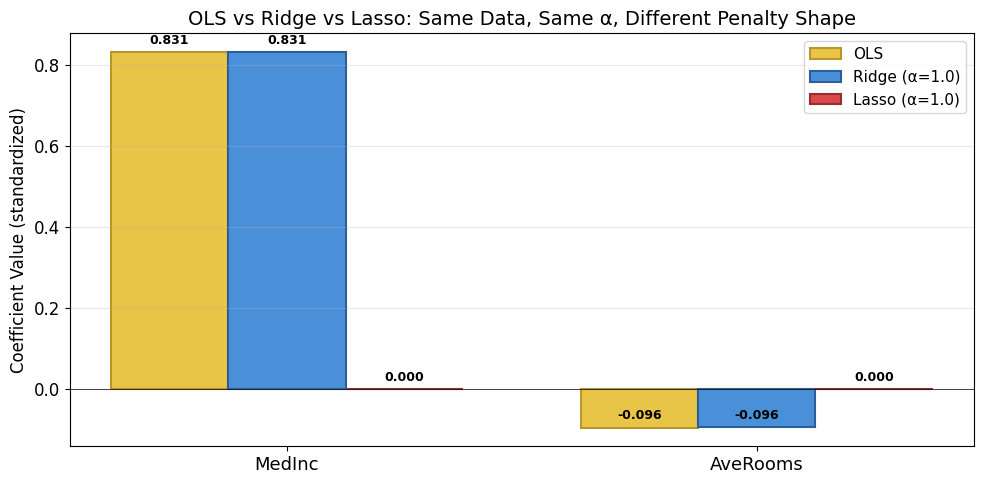

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(feature_cols))
bar_width = 0.25

ax.bar(x_pos - bar_width, ols.coef_, bar_width, label='OLS', color='#e8c547', edgecolor='#b8962a', linewidth=1.5)
ax.bar(x_pos, ridge.coef_, bar_width, label='Ridge (α=1.0)', color='#4a90d9', edgecolor='#2c5f99', linewidth=1.5)
ax.bar(x_pos + bar_width, lasso.coef_, bar_width, label='Lasso (α=1.0)', color='#d94a4a', edgecolor='#992c2c', linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(feature_cols, fontsize=13)
ax.set_ylabel('Coefficient Value (standardized)', fontsize=12)
ax.set_title('OLS vs Ridge vs Lasso: Same Data, Same α, Different Penalty Shape', fontsize=14)
ax.legend(fontsize=11)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Annotate coefficient values on bars
for i, (o, r, l) in enumerate(zip(ols.coef_, ridge.coef_, lasso.coef_)):
    ax.text(i - bar_width, o + 0.02, f'{o:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i, r + 0.02, f'{r:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + bar_width, l + 0.02, f'{l:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Key observations:**
- Ridge shrinks both coefficients toward zero, but neither reaches zero
- Lasso can push weaker coefficients to exactly zero — that's feature selection
- The stronger feature (MedInc) survives in both; the weaker one (AveRooms) is more affected
- Same regularization strength, completely different behavior — it's the *shape* of the penalty that matters

### What about a stronger penalty?

Let's crank up alpha and see what happens.

In [7]:
# Try a range of alpha values to see the progression
alphas_demo = [0.01, 0.1, 1.0, 5.0, 10.0]

print("Ridge coefficients as α increases:")
print("-" * 50)
for a in alphas_demo:
    r = Ridge(alpha=a, random_state=42).fit(X_train_scaled, y_train)
    print(f"  α={a:<6} MedInc={r.coef_[0]:>8.4f}   AveRooms={r.coef_[1]:>8.4f}")

print()
print("Lasso coefficients as α increases:")
print("-" * 50)
for a in alphas_demo:
    l = Lasso(alpha=a, random_state=42).fit(X_train_scaled, y_train)
    print(f"  α={a:<6} MedInc={l.coef_[0]:>8.4f}   AveRooms={l.coef_[1]:>8.4f}")

Ridge coefficients as α increases:
--------------------------------------------------
  α=0.01   MedInc=  0.8307   AveRooms= -0.0959
  α=0.1    MedInc=  0.8307   AveRooms= -0.0959
  α=1.0    MedInc=  0.8307   AveRooms= -0.0959
  α=5.0    MedInc=  0.8304   AveRooms= -0.0958
  α=10.0   MedInc=  0.8302   AveRooms= -0.0956

Lasso coefficients as α increases:
--------------------------------------------------
  α=0.01   MedInc=  0.8157   AveRooms= -0.0808
  α=0.1    MedInc=  0.6985   AveRooms= -0.0000
  α=1.0    MedInc=  0.0000   AveRooms=  0.0000
  α=5.0    MedInc=  0.0000   AveRooms=  0.0000
  α=10.0   MedInc=  0.0000   AveRooms=  0.0000


---
## Demo 2: The Regularization Path

Now let's use all 8 features in California Housing and watch what happens to every
coefficient as we sweep α from small (basically OLS) to large (everything squashed).
This is called the **regularization path**.

In [8]:
# Use all features this time
X_full = df[housing.feature_names].values
y_full = df['target'].values

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

scaler_full = StandardScaler()
X_train_f_scaled = scaler_full.fit_transform(X_train_f)
X_test_f_scaled = scaler_full.transform(X_test_f)

print(f"Using all {len(housing.feature_names)} features: {list(housing.feature_names)}")

Using all 8 features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [52]:
# Compute coefficients across a range of alpha values
alphas = np.logspace(-3, 4, 100)  # 0.001 to 10000

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    r = Ridge(alpha=a, random_state=42).fit(X_train_f_scaled, y_train_f)
    ridge_coefs.append(r.coef_)

    l = Lasso(alpha=a, random_state=42, max_iter=10000).fit(X_train_f_scaled, y_train_f)
    lasso_coefs.append(l.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

print(f"Computed coefficients for {len(alphas)} alpha values")
print(f"Alpha range: {alphas[0]:.4f} to {alphas[-1]:.1f}")

Computed coefficients for 100 alpha values
Alpha range: 0.0010 to 10000.0


### Ridge regularization path

Watch how all coefficients shrink smoothly toward zero as α increases.
No coefficient ever reaches exactly zero.

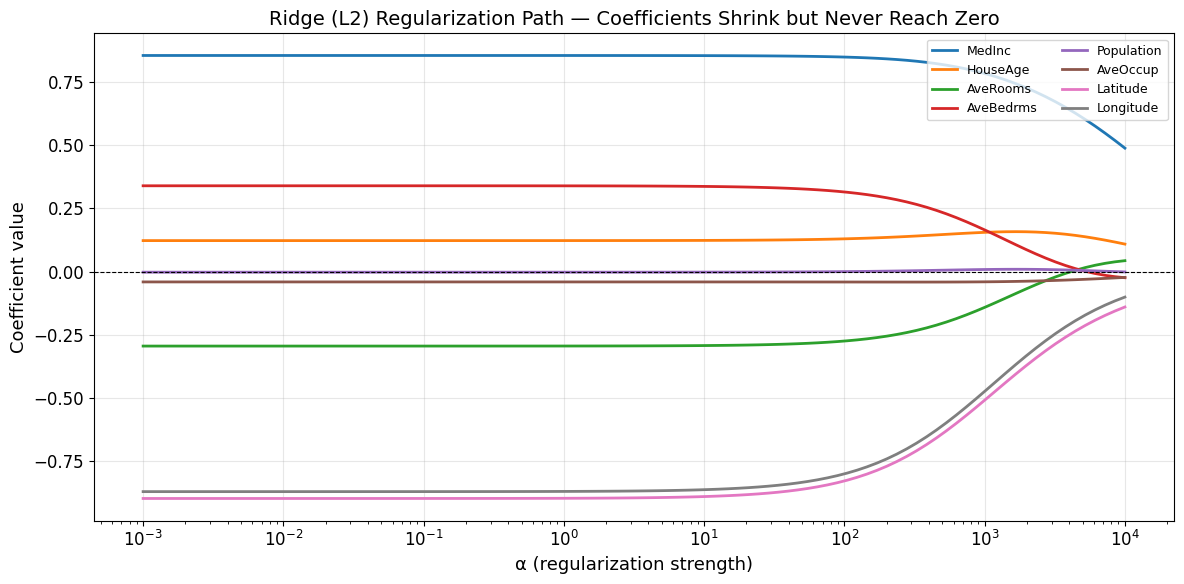

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(housing.feature_names):
    ax.plot(alphas, ridge_coefs[:, i], linewidth=2, label=name)

ax.set_xscale('log')
ax.set_xlabel('α (regularization strength)', fontsize=13)
ax.set_ylabel('Coefficient value', fontsize=13)
ax.set_title('Ridge (L2) Regularization Path — Coefficients Shrink but Never Reach Zero', fontsize=14)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Lasso regularization path

Now the same plot for Lasso. Watch coefficients drop to *exactly zero* at different
alpha values. The order they vanish tells you their relative importance.

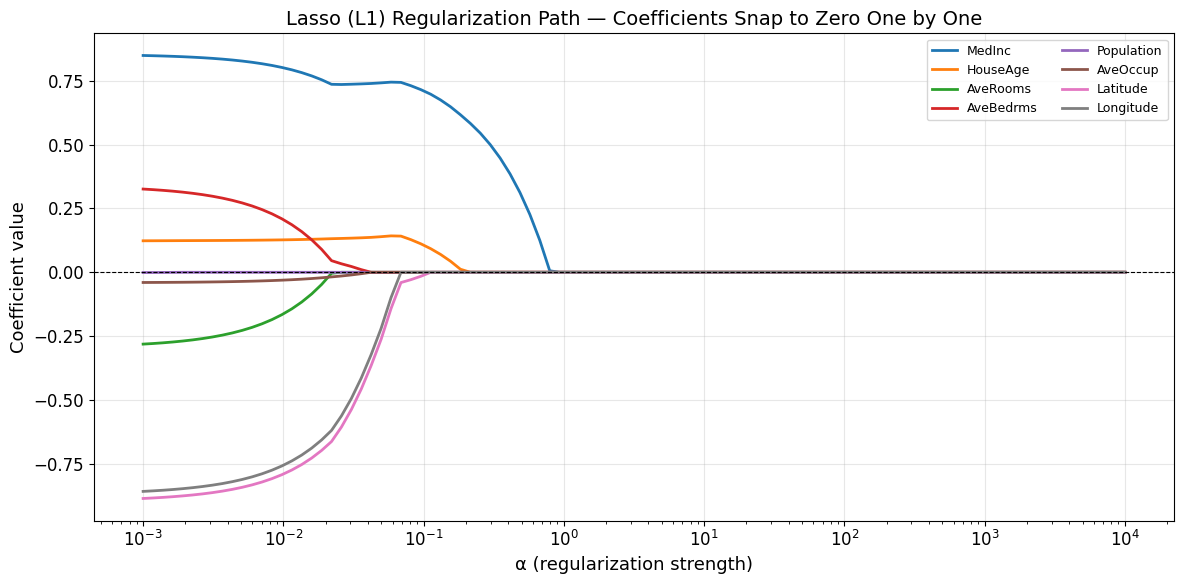

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(housing.feature_names):
    ax.plot(alphas, lasso_coefs[:, i], linewidth=2, label=name)

ax.set_xscale('log')
ax.set_xlabel('α (regularization strength)', fontsize=13)
ax.set_ylabel('Coefficient value', fontsize=13)
ax.set_title('Lasso (L1) Regularization Path — Coefficients Snap to Zero One by One', fontsize=14)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Side by side comparison

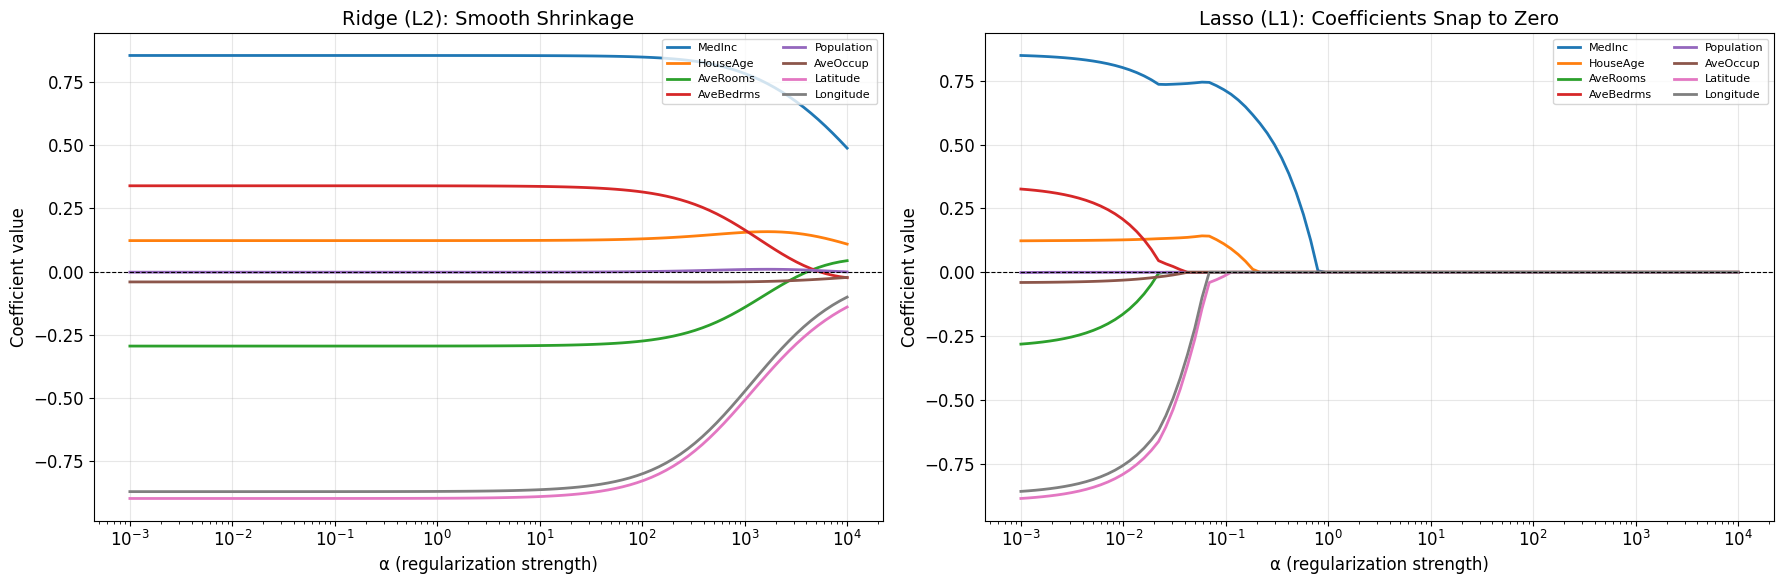

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Ridge path
for i, name in enumerate(housing.feature_names):
    ax1.plot(alphas, ridge_coefs[:, i], linewidth=2, label=name)
ax1.set_xscale('log')
ax1.set_xlabel('α (regularization strength)', fontsize=12)
ax1.set_ylabel('Coefficient value', fontsize=12)
ax1.set_title('Ridge (L2): Smooth Shrinkage', fontsize=14)
ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# Lasso path
for i, name in enumerate(housing.feature_names):
    ax2.plot(alphas, lasso_coefs[:, i], linewidth=2, label=name)
ax2.set_xscale('log')
ax2.set_xlabel('α (regularization strength)', fontsize=12)
ax2.set_ylabel('Coefficient value', fontsize=12)
ax2.set_title('Lasso (L1): Coefficients Snap to Zero', fontsize=14)
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax2.legend(loc='upper right', fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key observations:**
- Ridge (left): every coefficient shrinks smoothly toward zero, but none ever reaches it
- Lasso (right): coefficients hit exactly zero at different α values — that's automatic feature selection
- The last coefficient standing in Lasso is the most important feature (MedInc, as we'd expect)
- This is the regularization path in action — the geometric argument from the slides, now in real numbers

---
# Section 2: Gradient Descent Deep Dive

## Demo: Loss as a Landscape

When we fit a linear model ŷ = w₀ + w₁x, we're searching for the (w₀, w₁) pair
that minimizes the loss. With just two parameters, we can visualize the loss function
as a 3D surface: the horizontal axes are w₀ and w₁, and the height is the MSE at that
pair of values. Gradient descent is walking downhill on this surface.

### Generate some simple data

In [13]:
# Simple 1-feature dataset: y ≈ 2.5x + 1.0 with some noise
np.random.seed(42)
n_pts = 30
X_gd = np.random.uniform(-3, 3, n_pts)
y_gd = 2.5 * X_gd + 1.0 + np.random.normal(0, 1.5, n_pts)

print(f"Generated {n_pts} data points")
print(f"True relationship: y = 2.5x + 1.0 + noise")

Generated 30 data points
True relationship: y = 2.5x + 1.0 + noise


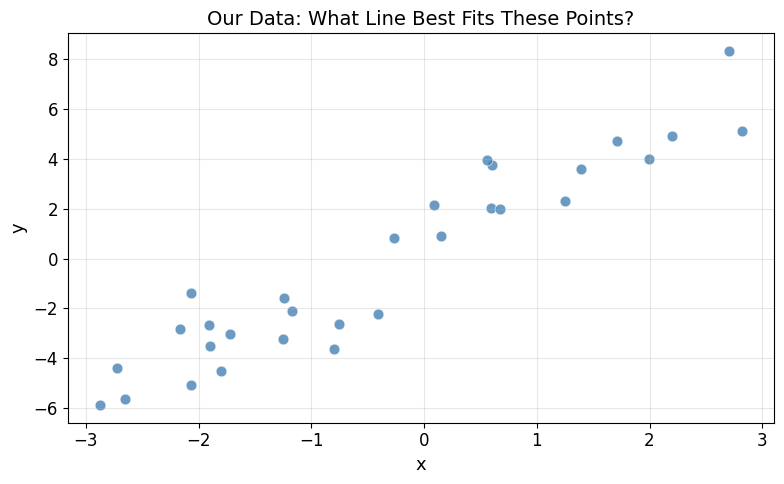

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_gd, y_gd, c='steelblue', edgecolors='white', linewidth=0.5, s=60, alpha=0.8)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Our Data: What Line Best Fits These Points?', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Compute the loss surface

For every possible (w₀, w₁) combination, compute the MSE. This gives us a surface
we can plot. The model is ŷ = w₀ + w₁x, so w₀ is the intercept and w₁ is the slope.

In [15]:
# Create a grid of (w0, w1) values
w0_range = np.linspace(-3, 5, 150)
w1_range = np.linspace(-1, 6, 150)
W0, W1 = np.meshgrid(w0_range, w1_range)

# Compute MSE at every point on the grid
loss_surface = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        preds = W0[i, j] + W1[i, j] * X_gd
        loss_surface[i, j] = np.mean((y_gd - preds) ** 2)

# Find the minimum on our grid (the OLS solution)
min_idx = np.unravel_index(loss_surface.argmin(), loss_surface.shape)
best_w0 = W0[min_idx]
best_w1 = W1[min_idx]
best_loss = loss_surface[min_idx]

print(f"Best parameters found: w₀ = {best_w0:.2f}, w₁ = {best_w1:.2f}")
print(f"Minimum MSE: {best_loss:.3f}")
print(f"(Recall true values: w₀ = 1.0, w₁ = 2.5)")

Best parameters found: w₀ = 0.60, w₁ = 2.15
Minimum MSE: 1.511
(Recall true values: w₀ = 1.0, w₁ = 2.5)


### The loss surface in 3D

Every point on this surface is a different line you could draw through the data.
The height is how wrong that line is (MSE). The bottom of the bowl is the best-fit line.
Gradient descent starts somewhere on this surface and walks downhill.

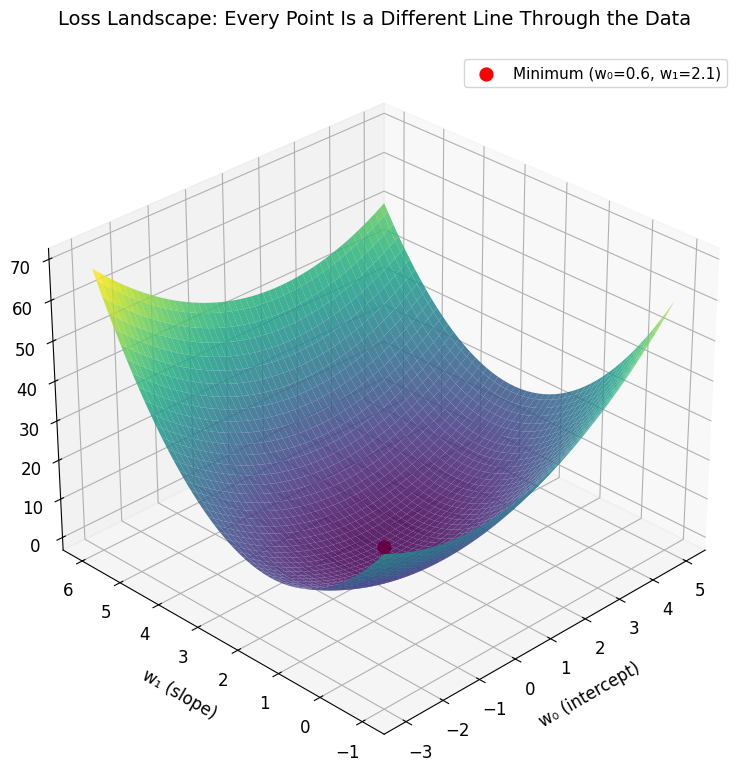

In [16]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(W0, W1, loss_surface, cmap='viridis', alpha=0.85, edgecolor='none')

# Mark the minimum
ax.scatter([best_w0], [best_w1], [best_loss], color='red', s=150, zorder=5,
           edgecolors='white', linewidth=2, label=f'Minimum (w₀={best_w0:.1f}, w₁={best_w1:.1f})')

ax.set_xlabel('w₀ (intercept)', fontsize=12, labelpad=10)
ax.set_ylabel('w₁ (slope)', fontsize=12, labelpad=10)
ax.set_zlabel('MSE Loss', fontsize=12, labelpad=10)
ax.set_title('Loss Landscape: Every Point Is a Different Line Through the Data', fontsize=14, pad=20)
ax.view_init(elev=30, azim=225)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

### The same surface from above (contour plot)

A contour plot is like a topographic map of the loss surface. Each ring
represents a set of (w₀, w₁) pairs that all produce the same loss.
The center is the minimum. Notice the elliptical shape; these are the
same contour ellipses from the regularization diagram.

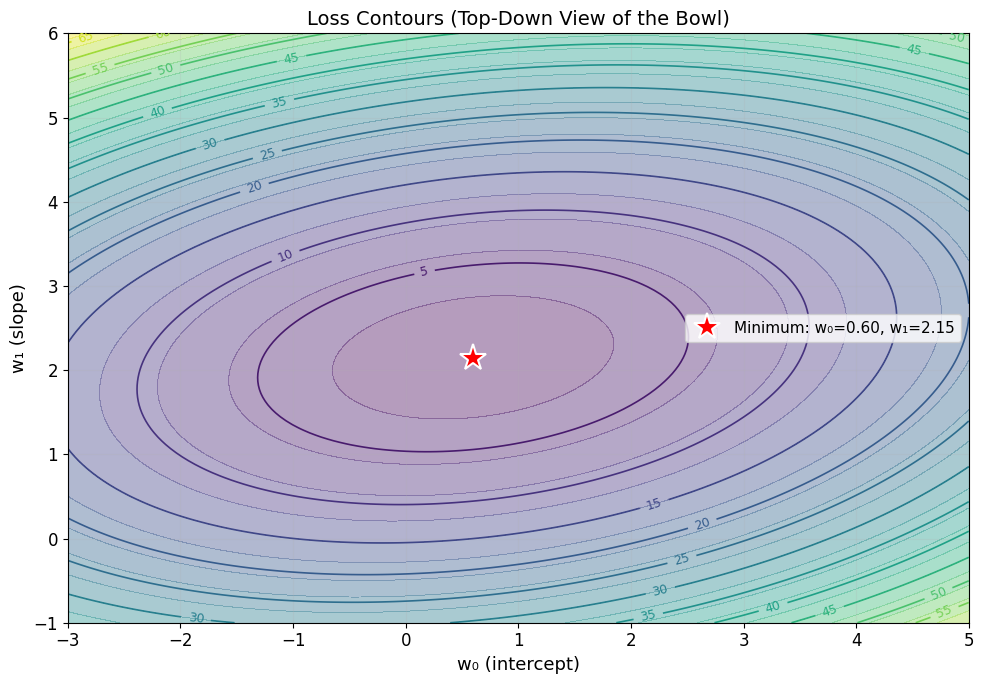

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))

# Filled contours for the background
cf = ax.contourf(W0, W1, loss_surface, levels=25, cmap='viridis', alpha=0.4)

# Line contours with labels
cs = ax.contour(W0, W1, loss_surface, levels=15, cmap='viridis', linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=9, fmt='%.0f')

# Mark the minimum
ax.plot(best_w0, best_w1, 'r*', markersize=20, markeredgecolor='white', markeredgewidth=1.5,
        label=f'Minimum: w₀={best_w0:.2f}, w₁={best_w1:.2f}')

ax.set_xlabel('w₀ (intercept)', fontsize=13)
ax.set_ylabel('w₁ (slope)', fontsize=13)
ax.set_title('Loss Contours (Top-Down View of the Bowl)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### How does regularization change the loss landscape?

In [18]:
alpha_lasso = 10.0 # Regularization strength for Lasso

# Compute Lasso loss at every point on the grid
loss_surface_lasso = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        preds = W0[i, j] + W1[i, j] * X_gd
        mse_loss = np.mean((y_gd - preds) ** 2)
        l1_penalty = alpha_lasso * (np.abs(W0[i, j]) + np.abs(W1[i, j])) # L1 penalty on coefficients
        loss_surface_lasso[i, j] = mse_loss + l1_penalty

# Find the minimum on our grid for Lasso
min_idx_lasso = np.unravel_index(loss_surface_lasso.argmin(), loss_surface_lasso.shape)
best_w0_lasso = W0[min_idx_lasso]
best_w1_lasso = W1[min_idx_lasso]
best_loss_lasso = loss_surface_lasso[min_idx_lasso]

print(f"Lasso best parameters found (α={alpha_lasso}): w₀ = {best_w0_lasso:.2f}, w₁ = {best_w1_lasso:.2f}")
print(f"Minimum Lasso Loss: {best_loss_lasso:.3f}")
print(f"  (Recall true values: w₀ = 1.0, w₁ = 2.5)")

Lasso best parameters found (α=10.0): w₀ = 0.01, w₁ = 0.36
Minimum Lasso Loss: 14.093
  (Recall true values: w₀ = 1.0, w₁ = 2.5)


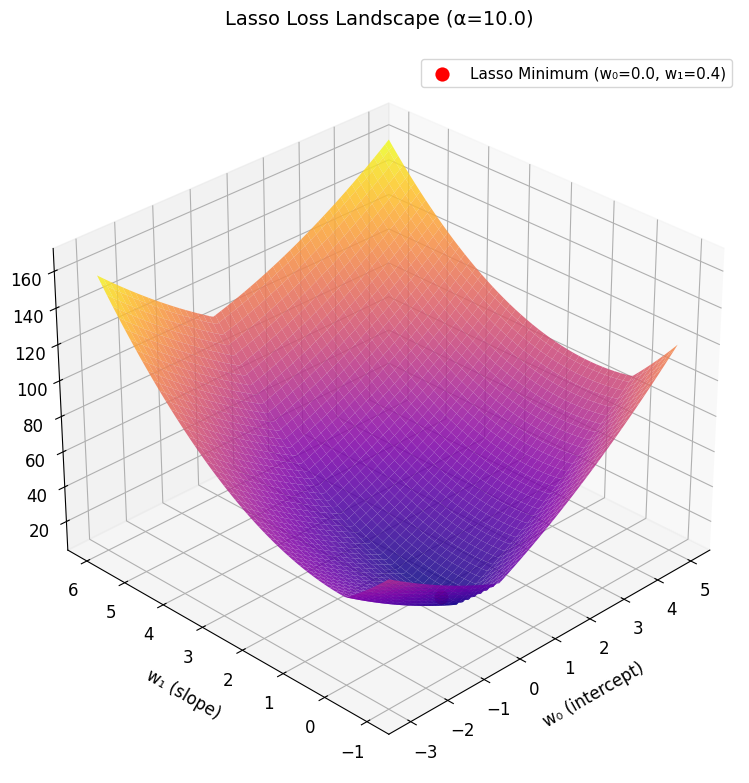

In [19]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(W0, W1, loss_surface_lasso, cmap='plasma', alpha=0.85, edgecolor='none')

# Mark the minimum
ax.scatter([best_w0_lasso], [best_w1_lasso], [best_loss_lasso], color='red', s=150, zorder=5,
           edgecolors='white', linewidth=2, label=f'Lasso Minimum (w₀={best_w0_lasso:.1f}, w₁={best_w1_lasso:.1f})')

ax.set_xlabel('w₀ (intercept)', fontsize=12, labelpad=10)
ax.set_ylabel('w₁ (slope)', fontsize=12, labelpad=10)
ax.set_zlabel('Lasso Loss', fontsize=12, labelpad=10)
ax.set_title(f'Lasso Loss Landscape (α={alpha_lasso})', fontsize=14, pad=20)
ax.view_init(elev=30, azim=225)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

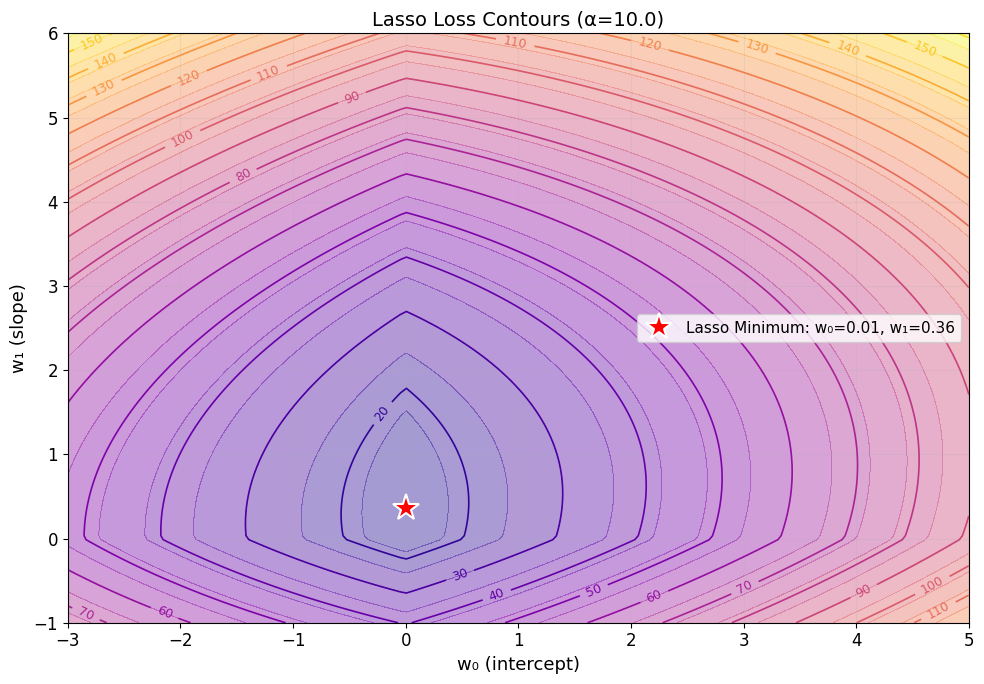

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

# Filled contours for the background
cf = ax.contourf(W0, W1, loss_surface_lasso, levels=25, cmap='plasma', alpha=0.4)

# Line contours with labels
cs = ax.contour(W0, W1, loss_surface_lasso, levels=15, cmap='plasma', linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=9, fmt='%.0f')

# Mark the minimum
ax.plot(best_w0_lasso, best_w1_lasso, 'r*', markersize=20, markeredgecolor='white', markeredgewidth=1.5,
        label=f'Lasso Minimum: w₀={best_w0_lasso:.2f}, w₁={best_w1_lasso:.2f}')

ax.set_xlabel('w₀ (intercept)', fontsize=13)
ax.set_ylabel('w₁ (slope)', fontsize=13)
ax.set_title(f'Lasso Loss Contours (α={alpha_lasso})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [21]:
alpha_ridge = 10.0 # Regularization strength for Ridge

# Compute Rige loss at every point on the grid
loss_surface_ridge = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        preds = W0[i, j] + W1[i, j] * X_gd
        mse_loss = np.mean((y_gd - preds) ** 2)
        l1_penalty = alpha_ridge * (np.abs(W0[i, j]) + np.abs(W1[i, j])) # L1 penalty on coefficients
        loss_surface_ridge[i, j] = mse_loss + l1_penalty

# Find the minimum on our grid for Ridge
min_idx_ridge = np.unravel_index(loss_surface_ridge.argmin(), loss_surface_ridge.shape)
best_w0_ridge = W0[min_idx_ridge]
best_w1_ridge = W1[min_idx_ridge]
best_loss_ridge = loss_surface_ridge[min_idx_ridge]

print(f"Ridge best parameters found (α={alpha_ridge}): w₀ = {best_w0_ridge:.2f}, w₁ = {best_w1_ridge:.2f}")
print(f"Minimum Ridge Loss: {best_loss_ridge:.3f}")
print(f"  (Recall true values: w₀ = 1.0, w₁ = 2.5)")

Ridge best parameters found (α=10.0): w₀ = 0.01, w₁ = 0.36
Minimum Ridge Loss: 14.093
  (Recall true values: w₀ = 1.0, w₁ = 2.5)


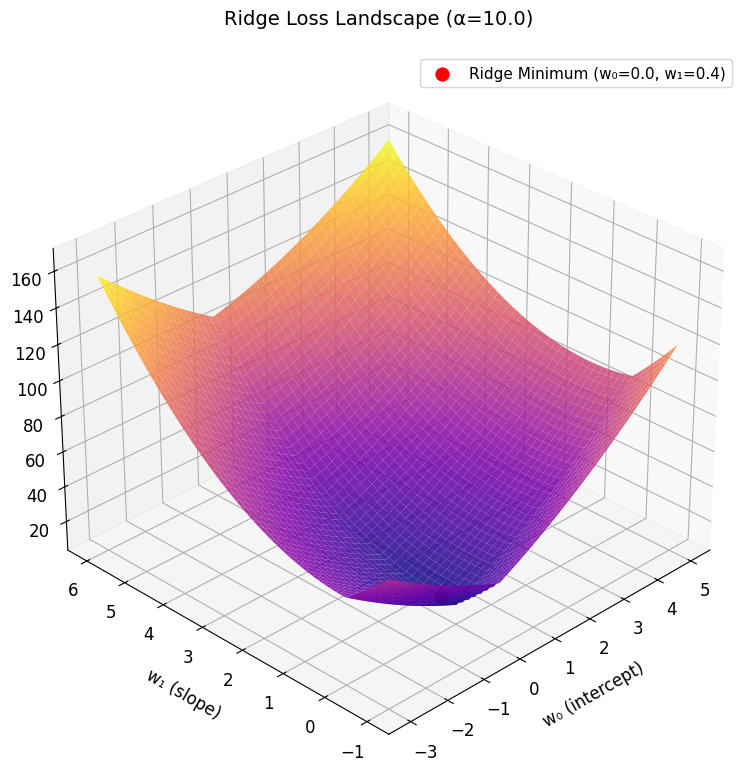

In [22]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(W0, W1, loss_surface_ridge, cmap='plasma', alpha=0.85, edgecolor='none')

# Mark the minimum
ax.scatter([best_w0_ridge], [best_w1_ridge], [best_loss_ridge], color='red', s=150, zorder=5,
           edgecolors='white', linewidth=2, label=f'Ridge Minimum (w₀={best_w0_ridge:.1f}, w₁={best_w1_ridge:.1f})')

ax.set_xlabel('w₀ (intercept)', fontsize=12, labelpad=10)
ax.set_ylabel('w₁ (slope)', fontsize=12, labelpad=10)
ax.set_zlabel('Ridge Loss', fontsize=12, labelpad=10)
ax.set_title(f'Ridge Loss Landscape (α={alpha_ridge})', fontsize=14, pad=20)
ax.view_init(elev=30, azim=225)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

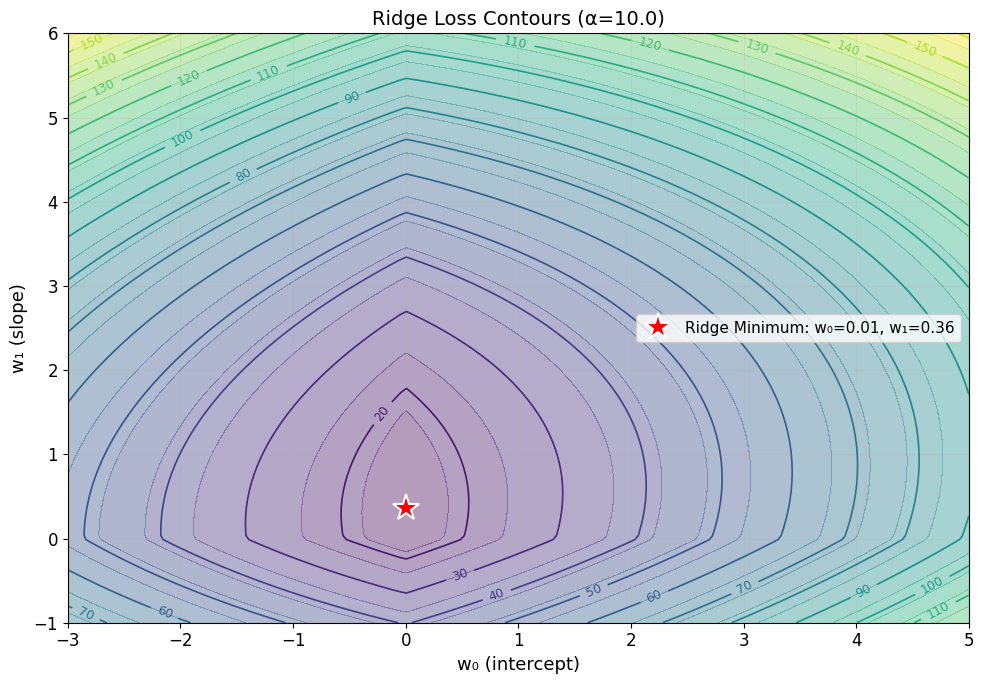

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

# Filled contours for the background
cf = ax.contourf(W0, W1, loss_surface_ridge, levels=25, cmap='viridis', alpha=0.4)

# Line contours with labels
cs = ax.contour(W0, W1, loss_surface_ridge, levels=15, cmap='viridis', linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=9, fmt='%.0f')

# Mark the minimum
ax.plot(best_w0_ridge, best_w1_ridge, 'r*', markersize=20, markeredgecolor='white', markeredgewidth=1.5,
        label=f'Ridge Minimum: w₀={best_w0_ridge:.2f}, w₁={best_w1_ridge:.2f}')

ax.set_xlabel('w₀ (intercept)', fontsize=13)
ax.set_ylabel('w₁ (slope)', fontsize=13)
ax.set_title(f'Ridge Loss Contours (α={alpha_ridge})', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**Key takeaways:**
- The loss surface for linear regression is a smooth bowl (convex) with one minimum
- Gradient descent walks downhill on this surface by following the negative gradient
- The contour ellipses are the same shapes from the regularization diagram: adding a
  penalty region to this picture is exactly what Ridge and Lasso do
- For neural networks, the surface is much more complex (non-convex, high-dimensional),
  but the idea of "walk downhill" is the same

---
# Section 3: Tree-Based Models

## Demo: Gini Impurity Worked Example

Decision trees choose splits by measuring how "pure" the resulting groups are.
Let's do the arithmetic by hand on a small dataset so you can see exactly what
the tree is computing at every node.

### The dataset

10 animals. We want to classify them as Cat or Dog based on their weight.

In [24]:
# 10 animals: predict Cat vs Dog from weight
animal_data = pd.DataFrame({
    'Weight': [4, 5, 6, 9, 7, 14, 18, 11, 20, 25],
    'Label':  ['Cat','Cat','Cat','Dog','Cat','Dog','Dog','Cat','Dog','Dog']
})

print(animal_data.to_string(index=False))
print(f"\nClass counts: {dict(animal_data['Label'].value_counts())}")

 Weight Label
      4   Cat
      5   Cat
      6   Cat
      9   Dog
      7   Cat
     14   Dog
     18   Dog
     11   Cat
     20   Dog
     25   Dog

Class counts: {'Cat': np.int64(5), 'Dog': np.int64(5)}


### Step 1: Parent node Gini

Before any split, all 10 samples are in one node. Gini impurity measures
how mixed this node is: Gini = 1 - p(Cat)² - p(Dog)²

In [25]:
labels = animal_data['Label'].values
weight = animal_data['Weight'].values
n = len(labels)

p_cat = np.sum(labels == 'Cat') / n
p_dog = np.sum(labels == 'Dog') / n

gini_parent = 1 - p_cat**2 - p_dog**2

print(f"Parent node: {np.sum(labels=='Cat')} cats, {np.sum(labels=='Dog')} dogs")
print(f"p(Cat) = {p_cat:.1f}, p(Dog) = {p_dog:.1f}")
print(f"Gini = 1 - {p_cat:.1f}² - {p_dog:.1f}² = 1 - {p_cat**2:.2f} - {p_dog**2:.2f} = {gini_parent:.3f}")
print(f"\n0.5 is the worst possible (maximum uncertainty for 2 classes)")

Parent node: 5 cats, 5 dogs
p(Cat) = 0.5, p(Dog) = 0.5
Gini = 1 - 0.5² - 0.5² = 1 - 0.25 - 0.25 = 0.500

0.5 is the worst possible (maximum uncertainty for 2 classes)


### Step 2: Evaluate candidate splits

Let's compare two candidate thresholds on weight. For each split, we compute
the Gini of each child node, then take the weighted average (weighted by how
many samples end up in each child).

In [26]:
def compute_split_gini(labels, feature, threshold):
    """Compute weighted Gini impurity for a binary split."""
    left_mask = feature <= threshold
    left = labels[left_mask]
    right = labels[~left_mask]
    n_total = len(labels)

    # Gini for each child
    def gini(group):
        if len(group) == 0:
            return 0
        p_cat = np.sum(group == 'Cat') / len(group)
        p_dog = np.sum(group == 'Dog') / len(group)
        return 1 - p_cat**2 - p_dog**2

    g_left = gini(left)
    g_right = gini(right)
    weighted = (len(left)/n_total) * g_left + (len(right)/n_total) * g_right

    return g_left, g_right, weighted, left, right

print("This function computes the weighted Gini for any split.")
print("We'll use it to compare two candidate thresholds.")

This function computes the weighted Gini for any split.
We'll use it to compare two candidate thresholds.


In [27]:
# Candidate split A: weight <= 7
g_left_a, g_right_a, weighted_a, left_a, right_a = compute_split_gini(labels, weight, 7)

print("SPLIT A: Weight <= 7")
print("=" * 50)
print(f"  Left  (weight <= 7): {np.sum(left_a=='Cat')} cats, {np.sum(left_a=='Dog')} dogs  (n={len(left_a)})")
print(f"    Gini = 1 - ({np.sum(left_a=='Cat')}/{len(left_a)})² - ({np.sum(left_a=='Dog')}/{len(left_a)})² = {g_left_a:.3f}")
print(f"  Right (weight > 7):  {np.sum(right_a=='Cat')} cats, {np.sum(right_a=='Dog')} dogs  (n={len(right_a)})")
print(f"    Gini = 1 - ({np.sum(right_a=='Cat')}/{len(right_a)})² - ({np.sum(right_a=='Dog')}/{len(right_a)})² = {g_right_a:.3f}")
print(f"  Weighted Gini = ({len(left_a)}/10) × {g_left_a:.3f} + ({len(right_a)}/10) × {g_right_a:.3f} = {weighted_a:.3f}")

SPLIT A: Weight <= 7
  Left  (weight <= 7): 4 cats, 0 dogs  (n=4)
    Gini = 1 - (4/4)² - (0/4)² = 0.000
  Right (weight > 7):  1 cats, 5 dogs  (n=6)
    Gini = 1 - (1/6)² - (5/6)² = 0.278
  Weighted Gini = (4/10) × 0.000 + (6/10) × 0.278 = 0.167


In [28]:
# Candidate split B: weight <= 9
g_left_b, g_right_b, weighted_b, left_b, right_b = compute_split_gini(labels, weight, 9)

print("SPLIT B: Weight <= 9")
print("=" * 50)
print(f"  Left  (weight <= 9): {np.sum(left_b=='Cat')} cats, {np.sum(left_b=='Dog')} dogs  (n={len(left_b)})")
print(f"    Gini = 1 - ({np.sum(left_b=='Cat')}/{len(left_b)})² - ({np.sum(left_b=='Dog')}/{len(left_b)})² = {g_left_b:.3f}")
print(f"  Right (weight > 9):  {np.sum(right_b=='Cat')} cats, {np.sum(right_b=='Dog')} dogs  (n={len(right_b)})")
print(f"    Gini = 1 - ({np.sum(right_b=='Cat')}/{len(right_b)})² - ({np.sum(right_b=='Dog')}/{len(right_b)})² = {g_right_b:.3f}")
print(f"  Weighted Gini = ({len(left_b)}/10) × {g_left_b:.3f} + ({len(right_b)}/10) × {g_right_b:.3f} = {weighted_b:.3f}")

SPLIT B: Weight <= 9
  Left  (weight <= 9): 4 cats, 1 dogs  (n=5)
    Gini = 1 - (4/5)² - (1/5)² = 0.320
  Right (weight > 9):  1 cats, 4 dogs  (n=5)
    Gini = 1 - (1/5)² - (4/5)² = 0.320
  Weighted Gini = (5/10) × 0.320 + (5/10) × 0.320 = 0.320


In [29]:
# Compare the two splits
print("COMPARISON")
print("=" * 50)
print(f"  Parent Gini:                    {gini_parent:.3f}")
print(f"  Split A (weight <= 7)  Gini:    {weighted_a:.3f}  (reduction: {gini_parent - weighted_a:.3f})")
print(f"  Split B (weight <= 9) Gini:    {weighted_b:.3f}  (reduction: {gini_parent - weighted_b:.3f})")
print(f"\n  Winner: {'Split A (weight <= 7)' if weighted_a < weighted_b else 'Split B (weight <= 9)'}")
print(f"  It produces purer child nodes, so the tree picks this one.")

COMPARISON
  Parent Gini:                    0.500
  Split A (weight <= 7)  Gini:    0.167  (reduction: 0.333)
  Split B (weight <= 9) Gini:    0.320  (reduction: 0.180)

  Winner: Split A (weight <= 7)
  It produces purer child nodes, so the tree picks this one.


### Visualizing the two splits

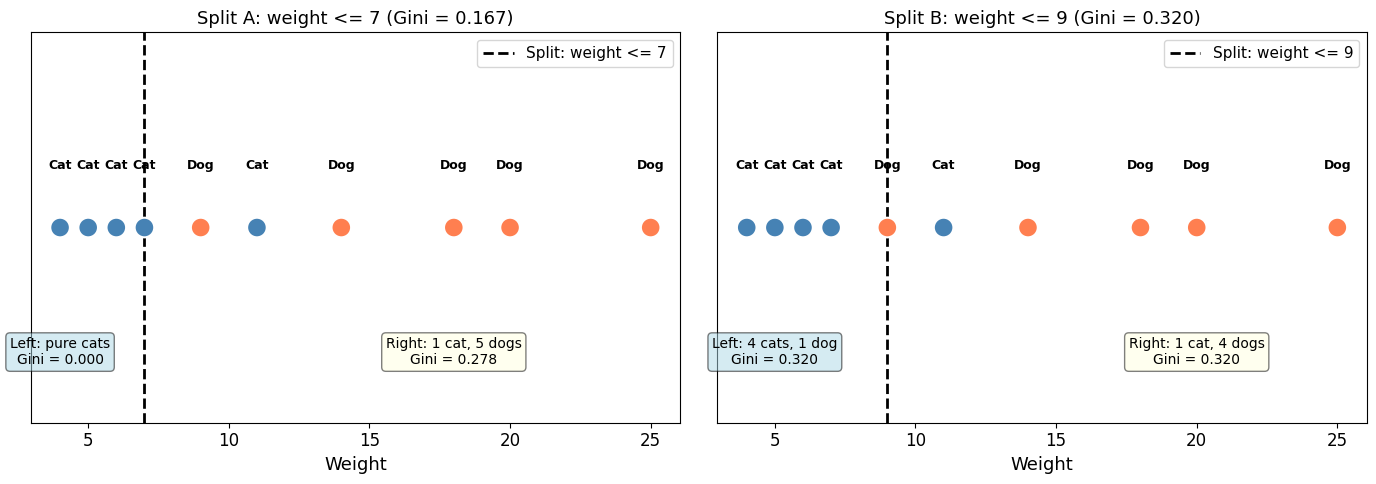

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue' if l == 'Cat' else 'coral' for l in labels]

# Split A: weight <= 7
ax1.scatter(weight, [0]*n, c=colors, s=200, edgecolors='white', linewidth=1.5, zorder=3)
for i, (w, l) in enumerate(zip(weight, labels)):
    ax1.text(w, 0.15, l, ha='center', fontsize=9, fontweight='bold')
ax1.axvline(x=7, color='black', linewidth=2, linestyle='--', label='Split: weight <= 7')
ax1.set_xlabel('Weight', fontsize=13)
ax1.set_title(f'Split A: weight <= 7 (Gini = {weighted_a:.3f})', fontsize=13)
ax1.set_ylim(-0.5, 0.5)
ax1.set_yticks([])
ax1.legend(fontsize=11)
ax1.text(4, -0.35, f'Left: pure cats\nGini = {g_left_a:.3f}', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax1.text(18, -0.35, f'Right: 1 cat, 5 dogs\nGini = {g_right_a:.3f}', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

# Split B: weight <= 9
ax2.scatter(weight, [0]*n, c=colors, s=200, edgecolors='white', linewidth=1.5, zorder=3)
for i, (w, l) in enumerate(zip(weight, labels)):
    ax2.text(w, 0.15, l, ha='center', fontsize=9, fontweight='bold')
ax2.axvline(x=9, color='black', linewidth=2, linestyle='--', label='Split: weight <= 9')
ax2.set_xlabel('Weight', fontsize=13)
ax2.set_title(f'Split B: weight <= 9 (Gini = {weighted_b:.3f})', fontsize=13)
ax2.set_ylim(-0.5, 0.5)
ax2.set_yticks([])
ax2.legend(fontsize=11)
ax2.text(5, -0.35, f'Left: 4 cats, 1 dog\nGini = {g_left_b:.3f}', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax2.text(20, -0.35, f'Right: 1 cat, 4 dogs\nGini = {g_right_b:.3f}', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()

**The takeaway:** A tree evaluates every possible threshold on every feature, computes
this same weighted Gini for each one, and picks the winner. The algorithm
is simple arithmetic repeated many times.

---
## Demo: How Gradient Boosting Corrects Errors

Gradient boosting builds trees sequentially. Each new tree doesn't fit the original
target; it fits the *residuals* (errors) from the current ensemble. Let's watch
this process unfold step by step.

### Generate a nonlinear regression problem

In [31]:
# Wavy function that a single shallow tree can't capture
np.random.seed(42)
X_boost = np.linspace(0, 10, 50).reshape(-1, 1)
y_boost = np.sin(X_boost.ravel()) + 0.5 * np.cos(2 * X_boost.ravel()) + np.random.normal(0, 0.2, 50)

print(f"Dataset: {len(y_boost)} points, nonlinear relationship")
print(f"Each boosting tree will use max_depth=2 (very simple)")
print(f"Learning rate = 0.3 (we only trust 30% of each tree's correction)")

Dataset: 50 points, nonlinear relationship
Each boosting tree will use max_depth=2 (very simple)
Learning rate = 0.3 (we only trust 30% of each tree's correction)


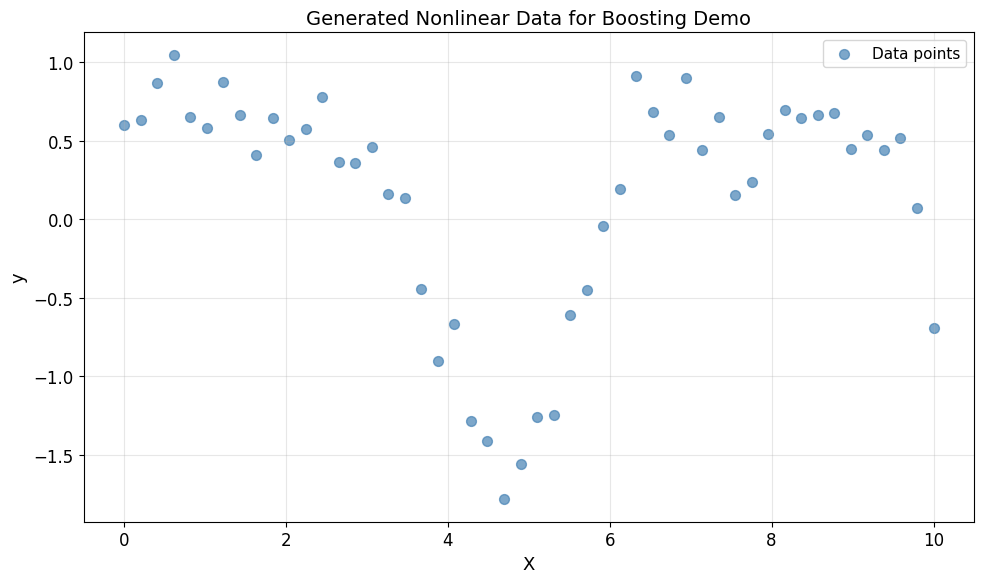

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_boost, y_boost, c='steelblue', s=50, alpha=0.7, label='Data points')
ax.set_xlabel('X', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Generated Nonlinear Data for Boosting Demo', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Run boosting manually, one round at a time

In [33]:
learning_rate = 0.3
n_rounds = 5

# Step 0: start with the simplest possible prediction (the mean)
current_pred = np.full_like(y_boost, y_boost.mean())
residuals = y_boost - current_pred

# Store history for plotting
pred_history = [current_pred.copy()]
residual_history = [residuals.copy()]
mse_history = [np.mean(residuals**2)]

print(f"Round 0 (baseline): predict mean = {y_boost.mean():.3f}, MSE = {mse_history[0]:.4f}")
print()

for i in range(n_rounds):
    # Fit a shallow tree to the RESIDUALS (not the original target)
    tree = DecisionTreeRegressor(max_depth=2, random_state=42)
    tree.fit(X_boost, residuals)
    tree_pred = tree.predict(X_boost)

    # Update ensemble: add a fraction (learning_rate) of this tree's prediction
    current_pred = current_pred + learning_rate * tree_pred
    residuals = y_boost - current_pred
    mse = np.mean(residuals**2)

    pred_history.append(current_pred.copy())
    residual_history.append(residuals.copy())
    mse_history.append(mse)

    print(f"Round {i+1}: fit tree to residuals, MSE = {mse:.4f} (was {mse_history[-2]:.4f})")

print(f"\nMSE reduced from {mse_history[0]:.4f} to {mse_history[-1]:.4f} in {n_rounds} rounds")

Round 0 (baseline): predict mean = 0.158, MSE = 0.5343

Round 1: fit tree to residuals, MSE = 0.3392 (was 0.5343)
Round 2: fit tree to residuals, MSE = 0.2166 (was 0.3392)
Round 3: fit tree to residuals, MSE = 0.1534 (was 0.2166)
Round 4: fit tree to residuals, MSE = 0.1333 (was 0.1534)
Round 5: fit tree to residuals, MSE = 0.0947 (was 0.1333)

MSE reduced from 0.5343 to 0.0947 in 5 rounds


### Watch the ensemble prediction improve

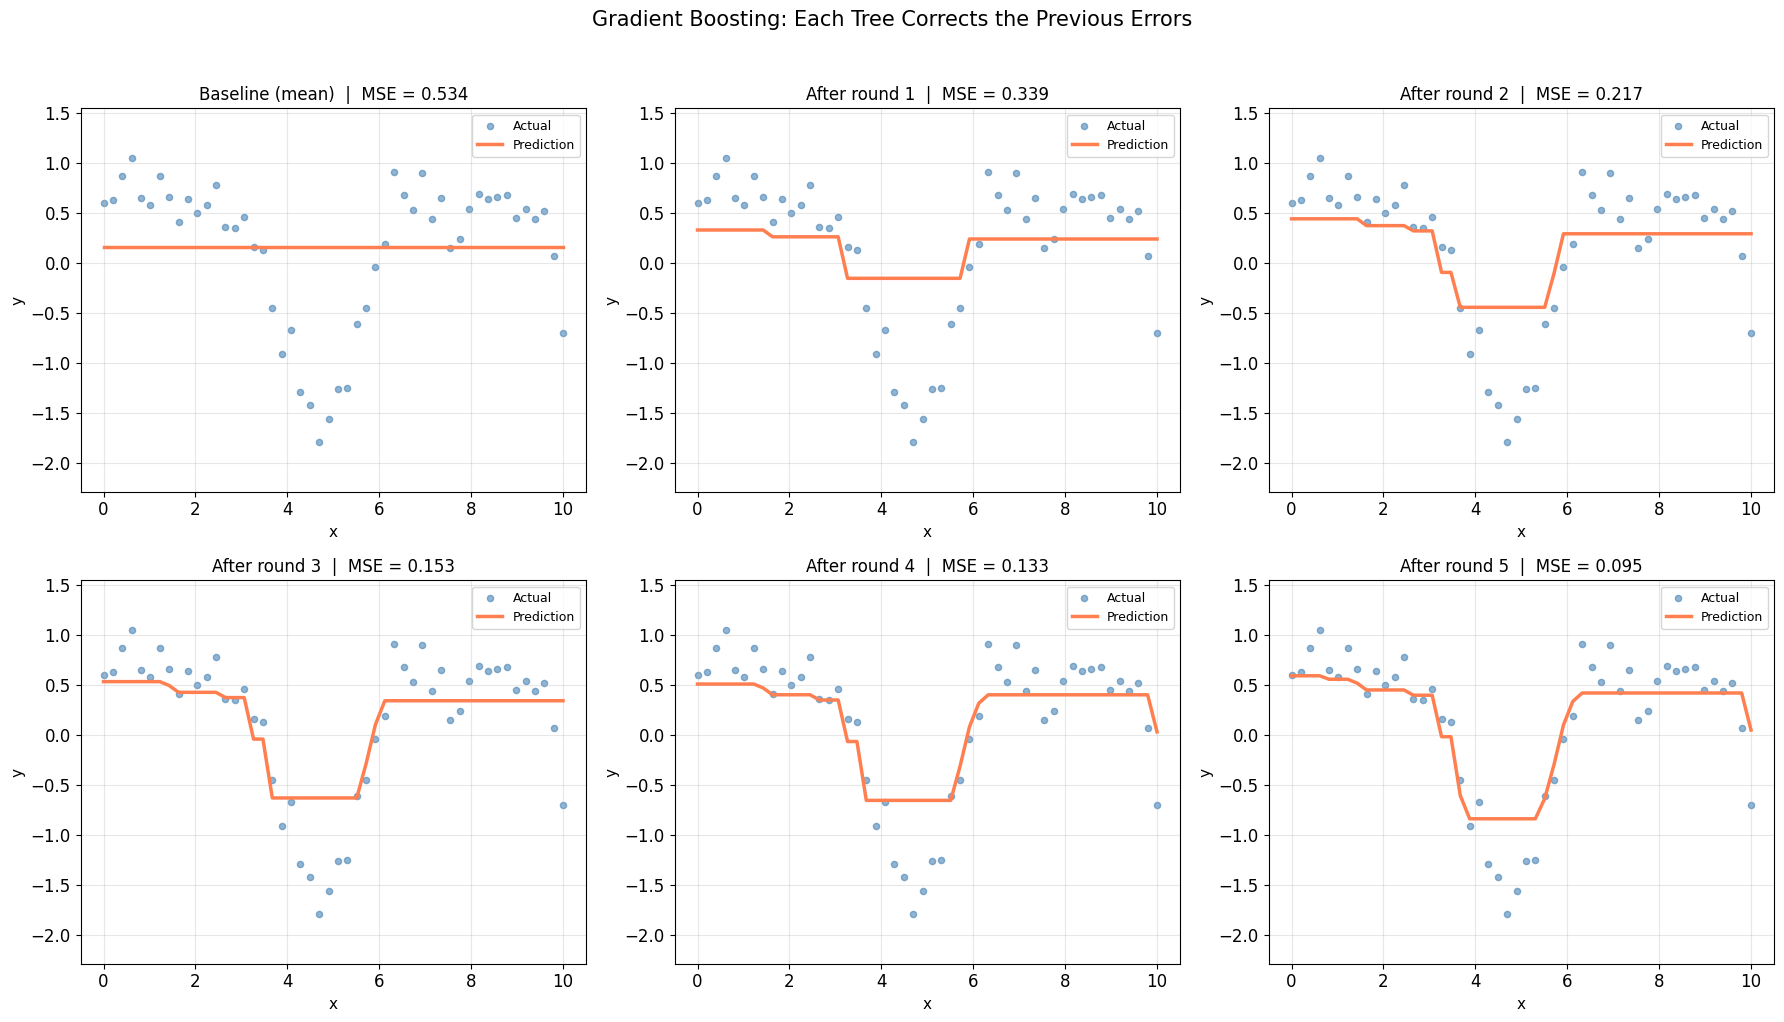

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

rounds_to_show = [0, 1, 2, 3, 4, 5]

for idx, round_num in enumerate(rounds_to_show):
    ax = axes[idx // 3][idx % 3]

    # Plot actual data
    ax.scatter(X_boost, y_boost, c='steelblue', s=20, alpha=0.6, label='Actual')

    # Plot current prediction
    sort_idx = np.argsort(X_boost.ravel())
    ax.plot(X_boost.ravel()[sort_idx], pred_history[round_num][sort_idx],
            c='coral', linewidth=2.5, label='Prediction')

    title = 'Baseline (mean)' if round_num == 0 else f'After round {round_num}'
    ax.set_title(f'{title}  |  MSE = {mse_history[round_num]:.3f}', fontsize=12)
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(y_boost.min() - 0.5, y_boost.max() + 0.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting: Each Tree Corrects the Previous Errors', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Watch the residuals shrink

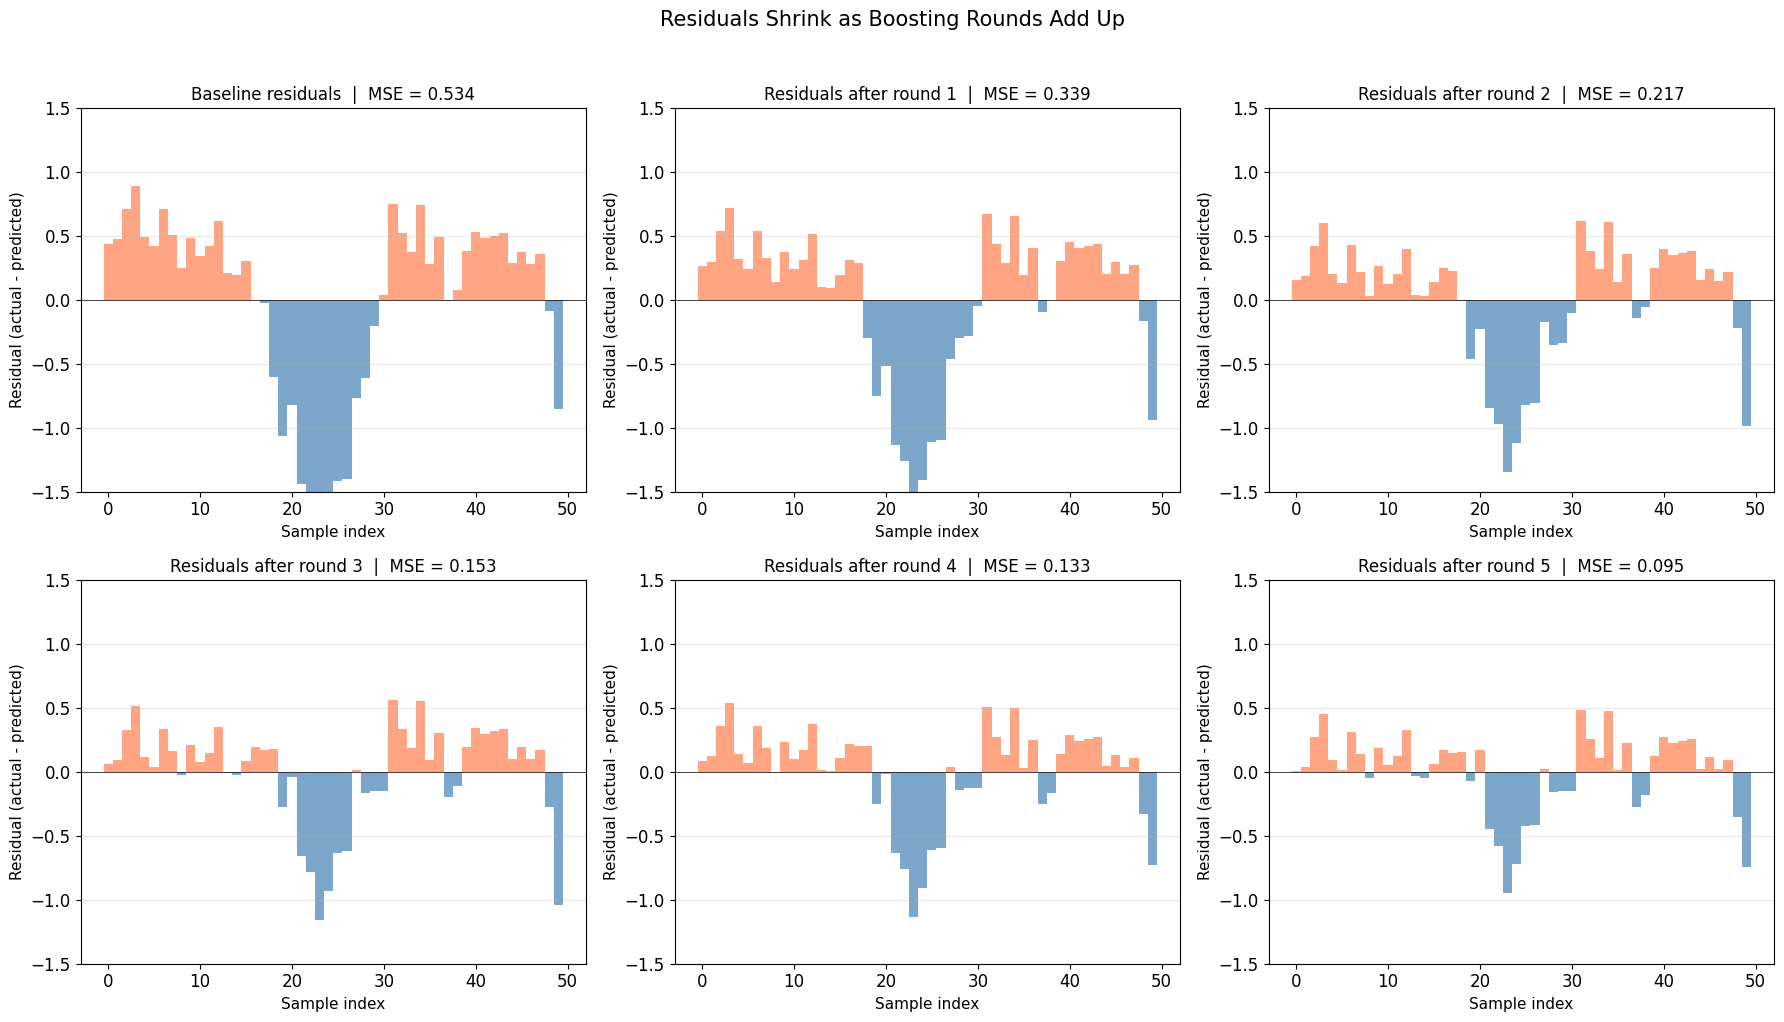

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, round_num in enumerate(rounds_to_show):
    ax = axes[idx // 3][idx % 3]

    ax.bar(range(len(y_boost)), residual_history[round_num],
           color=['coral' if r > 0 else 'steelblue' for r in residual_history[round_num]],
           alpha=0.7, width=1.0)

    title = 'Baseline residuals' if round_num == 0 else f'Residuals after round {round_num}'
    ax.set_title(f'{title}  |  MSE = {mse_history[round_num]:.3f}', fontsize=12)
    ax.set_xlabel('Sample index', fontsize=11)
    ax.set_ylabel('Residual (actual - predicted)', fontsize=11)
    ax.set_ylim(-1.5, 1.5)  # Fixed scale so shrinkage is visible
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Residuals Shrink as Boosting Rounds Add Up', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### MSE across rounds

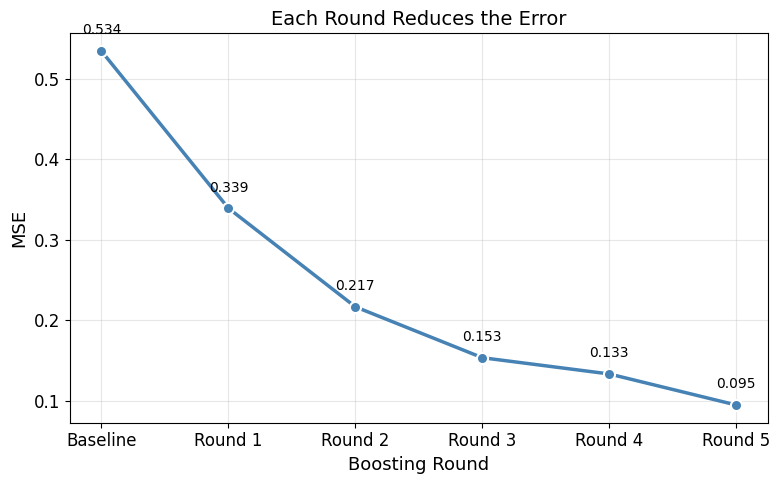

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(len(mse_history)), mse_history, 'o-', color='steelblue',
        linewidth=2.5, markersize=8, markeredgecolor='white', markeredgewidth=1.5)

for i, mse in enumerate(mse_history):
    ax.annotate(f'{mse:.3f}', (i, mse), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)

ax.set_xlabel('Boosting Round', fontsize=13)
ax.set_ylabel('MSE', fontsize=13)
ax.set_title('Each Round Reduces the Error', fontsize=14)
ax.set_xticks(range(len(mse_history)))
ax.set_xticklabels(['Baseline'] + [f'Round {i+1}' for i in range(n_rounds)])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key takeaways:**
- Boosting starts with a dumb prediction (the mean) and iteratively corrects it
- Each new tree fits the *residuals*, not the original target
- The learning rate controls how much of each tree's correction we trust (0.3 = cautious)
- Even very shallow trees (max_depth=2) can model complex patterns when combined
- This is why XGBoost uses many shallow trees rather than a few deep ones

---
# Section 4: Distance-Based Models

## Demo: The Curse of Dimensionality in Numbers

We said in Session 9 that "distances become less meaningful in high dimensions."
Let's see exactly how bad it gets. For random points in increasing dimensions,
we'll measure the ratio of nearest-neighbor distance to farthest-neighbor distance.
When that ratio approaches 1.0, nearest and farthest are basically the same distance
away, and the concept of "neighbor" breaks down.

In [37]:
np.random.seed(42)

dims_to_test = [2, 5, 10, 50, 100, 200, 500, 1000]
n_points = 200
n_sample = 50  # sample 50 query points for speed
ratios = []

for d in dims_to_test:
    points = np.random.uniform(0, 1, size=(n_points, d))
    sample_ratios = []
    for i in range(n_sample):
        dists = np.sqrt(np.sum((points - points[i])**2, axis=1))
        dists = dists[dists > 0]  # remove self-distance
        sample_ratios.append(dists.min() / dists.max())
    ratios.append(np.mean(sample_ratios))

print("Nearest / Farthest Distance Ratio")
print("=" * 40)
for d, r in zip(dims_to_test, ratios):
    bar = '█' * int(r * 40)
    print(f"  {d:>5}D:  {r:.3f}  {bar}")
print()
print("Closer to 1.0 = nearest and farthest are nearly the same distance.")
print("At that point, 'nearest neighbor' is almost meaningless.")

Nearest / Farthest Distance Ratio
      2D:  0.036  █
      5D:  0.169  ██████
     10D:  0.355  ██████████████
     50D:  0.641  █████████████████████████
    100D:  0.743  █████████████████████████████
    200D:  0.809  ████████████████████████████████
    500D:  0.875  ███████████████████████████████████
   1000D:  0.912  ████████████████████████████████████

Closer to 1.0 = nearest and farthest are nearly the same distance.
At that point, 'nearest neighbor' is almost meaningless.


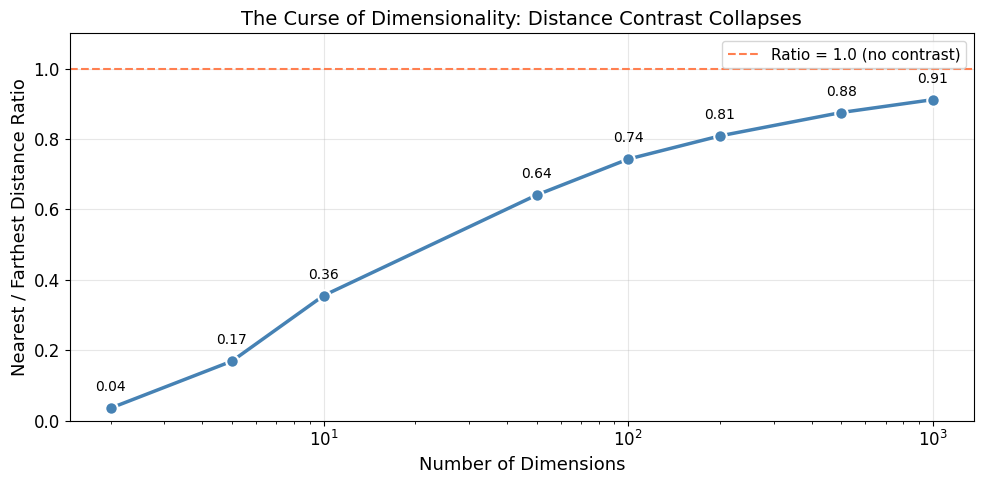

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dims_to_test, ratios, 'o-', color='steelblue', linewidth=2.5,
        markersize=9, markeredgecolor='white', markeredgewidth=1.5)

ax.axhline(y=1.0, color='coral', linewidth=1.5, linestyle='--', label='Ratio = 1.0 (no contrast)')

for d, r in zip(dims_to_test, ratios):
    ax.annotate(f'{r:.2f}', (d, r), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)

ax.set_xlabel('Number of Dimensions', fontsize=13)
ax.set_ylabel('Nearest / Farthest Distance Ratio', fontsize=13)
ax.set_title('The Curse of Dimensionality: Distance Contrast Collapses', fontsize=14)
ax.set_xscale('log')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Why this matters:**
- KNN relies on "nearest" neighbors being meaningfully closer than other points
- K-Means relies on points being closer to their own centroid than to other centroids
- When the ratio approaches 1.0, both assumptions break
- This is why dimensionality reduction (PCA) is often essential before distance-based methods

---
## Demo: Silhouette Score by Hand

You've used `silhouette_score()` as a black box. Let's open it up.
For a single point, the silhouette score measures: how much closer am I to my
own cluster than to the nearest other cluster?

In [39]:
# Clean 2D dataset with 3 clusters
np.random.seed(42)
X_sil, _ = make_blobs(n_samples=60, centers=3, cluster_std=0.8, random_state=42)

kmeans_sil = KMeans(n_clusters=3, random_state=42, n_init=10)
sil_labels = kmeans_sil.fit_predict(X_sil)

print(f"Clustered {len(X_sil)} points into 3 groups")
print(f"Cluster sizes: {dict(zip(*np.unique(sil_labels, return_counts=True)))}")

Clustered 60 points into 3 groups
Cluster sizes: {np.int32(0): np.int64(20), np.int32(1): np.int64(20), np.int32(2): np.int64(20)}


### Pick one point and compute its silhouette score manually

The formula for a single point:

- **a** = mean distance to all other points in my own cluster (cohesion)
- **b** = mean distance to the nearest *other* cluster (separation)
- **silhouette** = (b - a) / max(a, b)

Score near +1: well inside my cluster. Near 0: on the boundary. Near -1: probably in the wrong cluster.

In [40]:
# Pick point 0
point_idx = 0
point = X_sil[point_idx]
point_cluster = sil_labels[point_idx]

print(f"Point {point_idx}: coordinates = ({point[0]:.2f}, {point[1]:.2f}), assigned to cluster {point_cluster}")
print()

# a = mean distance to points in my own cluster
own_mask = (sil_labels == point_cluster) & (np.arange(len(X_sil)) != point_idx)
own_dists = np.sqrt(np.sum((X_sil[own_mask] - point)**2, axis=1))
a = np.mean(own_dists)
print(f"a (mean distance to own cluster): {a:.3f}")
print(f"  Computed from {own_mask.sum()} other points in cluster {point_cluster}")
print()

# b = mean distance to nearest OTHER cluster
other_clusters = [c for c in range(3) if c != point_cluster]
b = np.inf
for c in other_clusters:
    other_mask = sil_labels == c
    other_dists = np.sqrt(np.sum((X_sil[other_mask] - point)**2, axis=1))
    mean_dist = np.mean(other_dists)
    print(f"  Mean distance to cluster {c}: {mean_dist:.3f}  ({other_mask.sum()} points)")
    b = min(b, mean_dist)
print(f"b (nearest other cluster): {b:.3f}")
print()

# Silhouette score
sil_manual = (b - a) / max(a, b)
print(f"Silhouette = (b - a) / max(a, b) = ({b:.3f} - {a:.3f}) / {max(a, b):.3f} = {sil_manual:.3f}")
print(f"sklearn silhouette for this point: {silhouette_samples(X_sil, sil_labels)[point_idx]:.3f}")

Point 0: coordinates = (4.61, 3.22), assigned to cluster 2

a (mean distance to own cluster): 1.435
  Computed from 19 other points in cluster 2

  Mean distance to cluster 0: 9.193  (20 points)
  Mean distance to cluster 1: 15.227  (20 points)
b (nearest other cluster): 9.193

Silhouette = (b - a) / max(a, b) = (9.193 - 1.435) / 9.193 = 0.844
sklearn silhouette for this point: 0.844


### Silhouette plot for all points

Compute the silhouette for every point and visualize. Well-clustered data
has consistently high bars across all clusters.

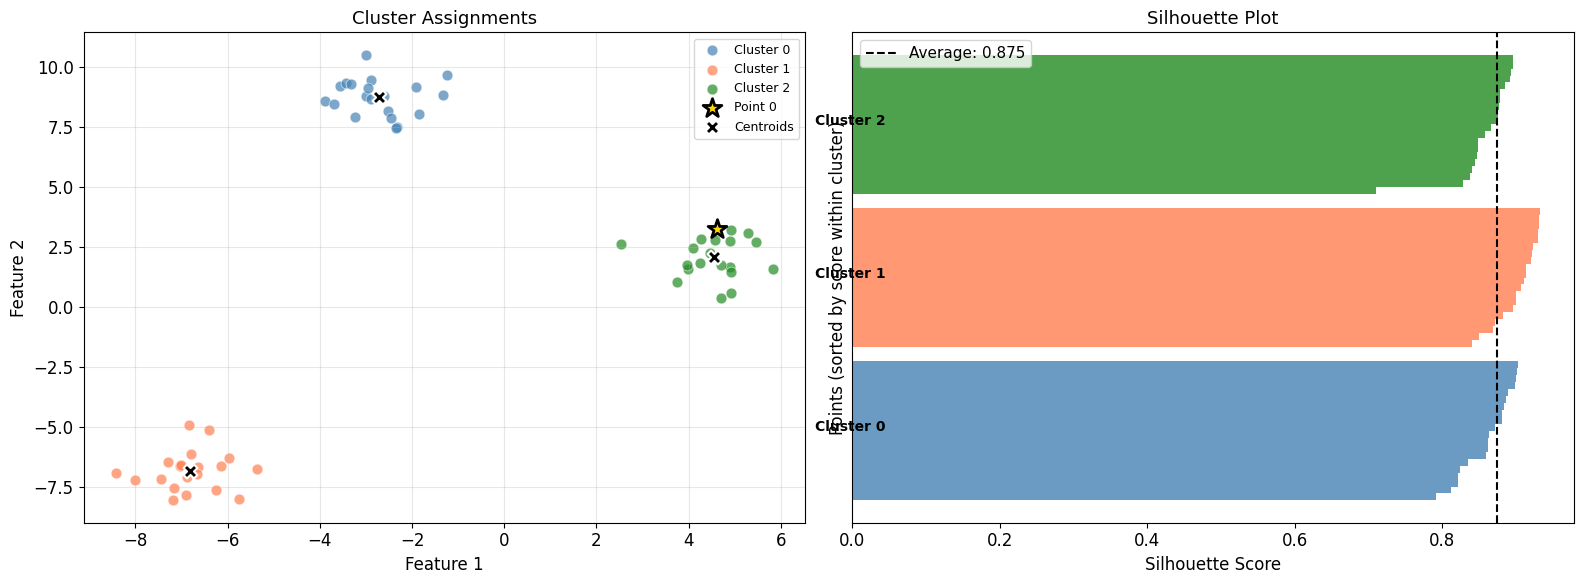

In [41]:
sil_scores = silhouette_samples(X_sil, sil_labels)
avg_score = np.mean(sil_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter plot with clusters and the selected point highlighted
cluster_colors = ['steelblue', 'coral', 'forestgreen']
for c in range(3):
    mask = sil_labels == c
    ax1.scatter(X_sil[mask, 0], X_sil[mask, 1], c=cluster_colors[c],
               s=60, alpha=0.7, edgecolors='white', linewidth=0.5, label=f'Cluster {c}')
ax1.scatter(point[0], point[1], c='gold', s=200, edgecolors='black',
            linewidth=2, zorder=5, marker='*', label=f'Point {point_idx}')
ax1.scatter(kmeans_sil.cluster_centers_[:, 0], kmeans_sil.cluster_centers_[:, 1],
            c='black', s=100, marker='X', edgecolors='white', linewidth=1.5,
            zorder=5, label='Centroids')
ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Feature 2', fontsize=12)
ax1.set_title('Cluster Assignments', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: silhouette plot
y_lower = 0
for c in range(3):
    cluster_sil = sil_scores[sil_labels == c]
    cluster_sil.sort()
    y_upper = y_lower + len(cluster_sil)
    ax2.barh(range(y_lower, y_upper), cluster_sil,
             height=1.0, color=cluster_colors[c], edgecolor='none', alpha=0.8)
    ax2.text(-0.05, y_lower + len(cluster_sil)/2, f'Cluster {c}',
             fontsize=10, fontweight='bold', va='center')
    y_lower = y_upper + 2

ax2.axvline(x=avg_score, color='black', linewidth=1.5, linestyle='--',
            label=f'Average: {avg_score:.3f}')
ax2.set_xlabel('Silhouette Score', fontsize=12)
ax2.set_ylabel('Points (sorted by score within cluster)', fontsize=12)
ax2.set_title('Silhouette Plot', fontsize=13)
ax2.set_yticks([])
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## Demo: Why Feature Scaling Matters for K-Means

When features have very different scales, distance is dominated by the
large-scale feature. K-Means effectively ignores the small-scale feature.
Let's see this with age (20-60) vs income (20,000-100,000).

In [42]:
# Generate data with two very different scales
np.random.seed(42)
age = np.concatenate([
    np.random.normal(25, 3, 40),   # Young, low income
    np.random.normal(45, 5, 30),   # Older, high income
    np.random.normal(35, 4, 30),   # Middle age, middle income
])
income = np.concatenate([
    np.random.normal(30000, 5000, 40),
    np.random.normal(80000, 10000, 30),
    np.random.normal(55000, 8000, 30),
])

X_unscaled = np.column_stack([age, income])

print(f"Age range:    {age.min():.0f} to {age.max():.0f}  (spread: ~{age.std():.0f})")
print(f"Income range: {income.min():.0f} to {income.max():.0f}  (spread: ~{income.std():.0f})")
print(f"\nIncome values are ~1000x larger than age values.")
print(f"Without scaling, Euclidean distance is almost entirely determined by income.")

Age range:    19 to 52  (spread: ~9)
Income range: 20406 to 98968  (spread: ~22527)

Income values are ~1000x larger than age values.
Without scaling, Euclidean distance is almost entirely determined by income.


In [43]:
# Cluster on unscaled data
km_unscaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_unscaled = km_unscaled.fit_predict(X_unscaled)

# Scale, then cluster
scaler_demo = StandardScaler()
X_demo_scaled = scaler_demo.fit_transform(X_unscaled)
km_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_demo_scaled)


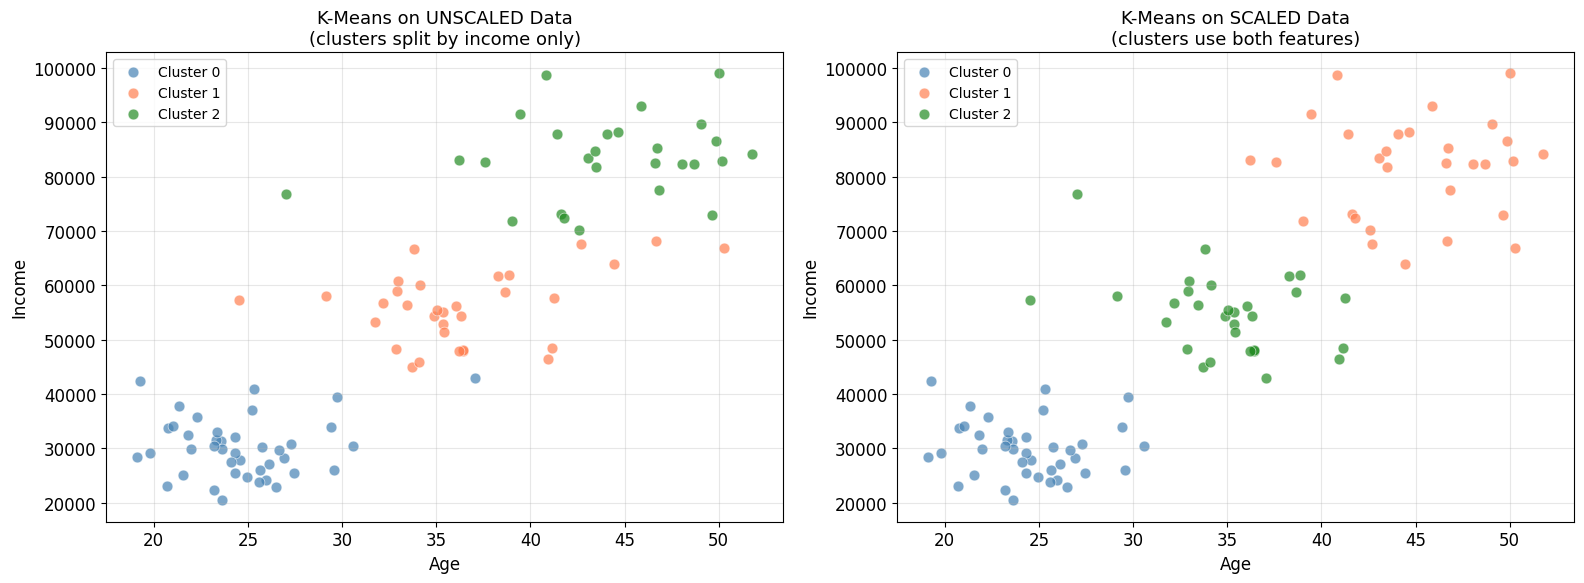

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = ['steelblue', 'coral', 'forestgreen']

# Unscaled
for c in range(3):
    mask = labels_unscaled == c
    ax1.scatter(age[mask], income[mask], c=cluster_colors[c],
               s=60, alpha=0.7, edgecolors='white', linewidth=0.5, label=f'Cluster {c}')
ax1.set_xlabel('Age', fontsize=12)
ax1.set_ylabel('Income', fontsize=12)
ax1.set_title('K-Means on UNSCALED Data\n(clusters split by income only)', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Scaled
for c in range(3):
    mask = labels_scaled == c
    ax2.scatter(age[mask], income[mask], c=cluster_colors[c],
               s=60, alpha=0.7, edgecolors='white', linewidth=0.5, label=f'Cluster {c}')
ax2.set_xlabel('Age', fontsize=12)
ax2.set_ylabel('Income', fontsize=12)
ax2.set_title('K-Means on SCALED Data\n(clusters use both features)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key takeaways:**
- Without scaling, K-Means clusters almost entirely on the large-scale feature (income)
- After scaling, both features contribute equally to distance, and clusters reflect structure in both dimensions
- The same principle applies to KNN: unscaled features mean your "neighbors" are determined by whichever feature has the biggest numbers
- Always scale before any distance-based method

---
# Section 5: Dimensionality Reduction

## Demo: What PCA Components Actually Are

Each principal component is a weighted combination of your original features.
Those weights are called **loadings**, and they tell you what each component
"means" in terms of the original data. Let's look at them on a real dataset.

In [45]:
# Load the Wine dataset (13 chemical measurements of Italian wines)
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
wine_features = wine.feature_names

print(f"Wine dataset: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")
print(f"Features: {list(wine_features)}")
print(f"Classes: {list(wine.target_names)}")

Wine dataset: 178 samples, 13 features
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [46]:
# Standardize (critical: PCA maximizes variance, so unscaled features dominate)
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# Fit PCA with 2 components
pca_wine = PCA(n_components=2, random_state=42)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

print(f"Reduced from {X_wine.shape[1]} features to {X_wine_pca.shape[1]} components")
print(f"PC1 explains {pca_wine.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains {pca_wine.explained_variance_ratio_[1]:.1%} of variance")
print(f"Total: {sum(pca_wine.explained_variance_ratio_):.1%}")

Reduced from 13 features to 2 components
PC1 explains 36.2% of variance
PC2 explains 19.2% of variance
Total: 55.4%


### The loadings: what each component is made of

PC1 = 0.14 × alcohol + (-0.25) × malic_acid + ... (a weighted sum of all 13 features).
Features with large positive loadings push a point's PC1 score up;
large negative loadings push it down.

In [47]:
# Show PC1 loadings sorted by magnitude
pc1_loadings = pca_wine.components_[0]
sorted_idx = np.argsort(np.abs(pc1_loadings))[::-1]

print("PC1 Loadings (sorted by magnitude)")
print("=" * 45)
for i in sorted_idx:
    bar = '█' * int(abs(pc1_loadings[i]) * 40)
    sign = '+' if pc1_loadings[i] > 0 else '-'
    print(f"  {wine_features[i]:>30s}: {sign}{abs(pc1_loadings[i]):.3f}  {bar}")

PC1 Loadings (sorted by magnitude)
                      flavanoids: +0.423  ████████████████
                   total_phenols: +0.395  ███████████████
    od280/od315_of_diluted_wines: +0.376  ███████████████
                 proanthocyanins: +0.313  ████████████
            nonflavanoid_phenols: -0.299  ███████████
                             hue: +0.297  ███████████
                         proline: +0.287  ███████████
                      malic_acid: -0.245  █████████
               alcalinity_of_ash: -0.239  █████████
                         alcohol: +0.144  █████
                       magnesium: +0.142  █████
                 color_intensity: -0.089  ███
                             ash: -0.002  


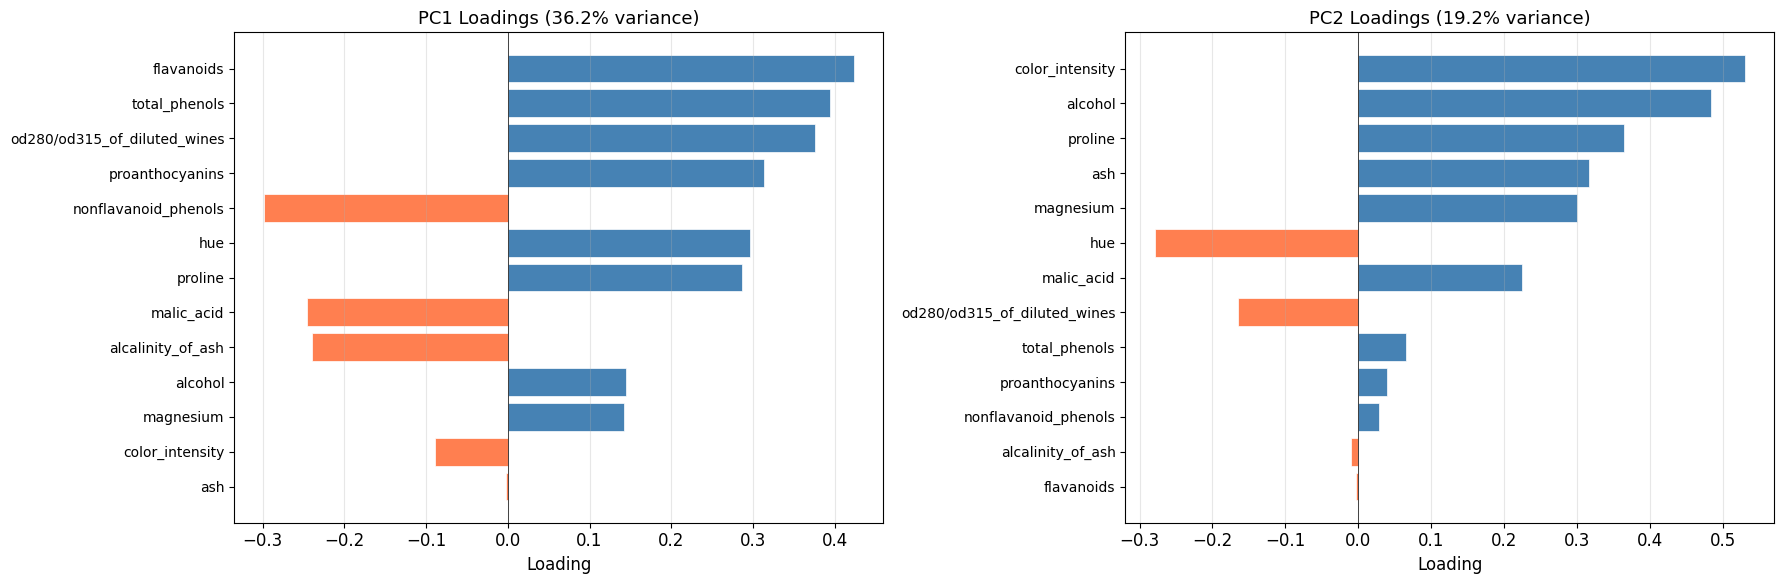

In [48]:
# Visualize loadings for PC1 and PC2 as bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PC1 loadings
colors_pc1 = ['steelblue' if v > 0 else 'coral' for v in pc1_loadings[sorted_idx]]
ax1.barh(range(len(wine_features)), pc1_loadings[sorted_idx], color=colors_pc1,
         edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(wine_features)))
ax1.set_yticklabels([wine_features[i] for i in sorted_idx], fontsize=10)
ax1.set_xlabel('Loading', fontsize=12)
ax1.set_title(f'PC1 Loadings ({pca_wine.explained_variance_ratio_[0]:.1%} variance)', fontsize=13)
ax1.axvline(x=0, color='black', linewidth=0.5)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# PC2 loadings
pc2_loadings = pca_wine.components_[1]
sorted_idx_2 = np.argsort(np.abs(pc2_loadings))[::-1]
colors_pc2 = ['steelblue' if v > 0 else 'coral' for v in pc2_loadings[sorted_idx_2]]
ax2.barh(range(len(wine_features)), pc2_loadings[sorted_idx_2], color=colors_pc2,
         edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(wine_features)))
ax2.set_yticklabels([wine_features[i] for i in sorted_idx_2], fontsize=10)
ax2.set_xlabel('Loading', fontsize=12)
ax2.set_title(f'PC2 Loadings ({pca_wine.explained_variance_ratio_[1]:.1%} variance)', fontsize=13)
ax2.axvline(x=0, color='black', linewidth=0.5)
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Manual projection: PCA is just a dot product

Let's take one wine sample and compute its PC1 score by hand.
The PC1 score is the dot product of the (standardized) feature values
with the PC1 loadings vector. That's all `pca.transform()` does.

In [49]:
# Pick the first wine sample
sample_idx = 0
sample_scaled = X_wine_scaled[sample_idx]

print(f"Wine sample {sample_idx} (standardized feature values):")
print("-" * 50)
for name, val in zip(wine_features, sample_scaled):
    print(f"  {name:>30s}: {val:+.3f}")

Wine sample 0 (standardized feature values):
--------------------------------------------------
                         alcohol: +1.519
                      malic_acid: -0.562
                             ash: +0.232
               alcalinity_of_ash: -1.170
                       magnesium: +1.914
                   total_phenols: +0.809
                      flavanoids: +1.035
            nonflavanoid_phenols: -0.660
                 proanthocyanins: +1.225
                 color_intensity: +0.252
                             hue: +0.362
    od280/od315_of_diluted_wines: +1.848
                         proline: +1.013


In [50]:
# Compute PC1 score manually: dot product of sample with PC1 loadings
print("Computing PC1 score as a dot product:")
print("=" * 55)
running_sum = 0
for name, val, loading in zip(wine_features, sample_scaled, pc1_loadings):
    contribution = val * loading
    running_sum += contribution
    print(f"  {val:+.3f} × {loading:+.3f} = {contribution:+.3f}   ({name})")

print(f"{'':>30s}  --------")
print(f"{'Manual PC1 score':>30s} = {running_sum:+.4f}")
print(f"{'sklearn PC1 score':>30s} = {X_wine_pca[sample_idx, 0]:+.4f}")
print(f"\nThey match: {np.isclose(running_sum, X_wine_pca[sample_idx, 0])}")
print(f"\nThat's it. PCA transform is a dot product (matrix multiplication).")

Computing PC1 score as a dot product:
  +1.519 × +0.144 = +0.219   (alcohol)
  -0.562 × -0.245 = +0.138   (malic_acid)
  +0.232 × -0.002 = -0.000   (ash)
  -1.170 × -0.239 = +0.280   (alcalinity_of_ash)
  +1.914 × +0.142 = +0.272   (magnesium)
  +0.809 × +0.395 = +0.319   (total_phenols)
  +1.035 × +0.423 = +0.438   (flavanoids)
  -0.660 × -0.299 = +0.197   (nonflavanoid_phenols)
  +1.225 × +0.313 = +0.384   (proanthocyanins)
  +0.252 × -0.089 = -0.022   (color_intensity)
  +0.362 × +0.297 = +0.107   (hue)
  +1.848 × +0.376 = +0.695   (od280/od315_of_diluted_wines)
  +1.013 × +0.287 = +0.290   (proline)
                                --------
              Manual PC1 score = +3.3168
             sklearn PC1 score = +3.3168

They match: True

That's it. PCA transform is a dot product (matrix multiplication).


### The PCA projection colored by wine class

Even though PCA is unsupervised (it doesn't see the labels), the
2D projection often separates classes because the directions of
maximum variance tend to align with meaningful structure.

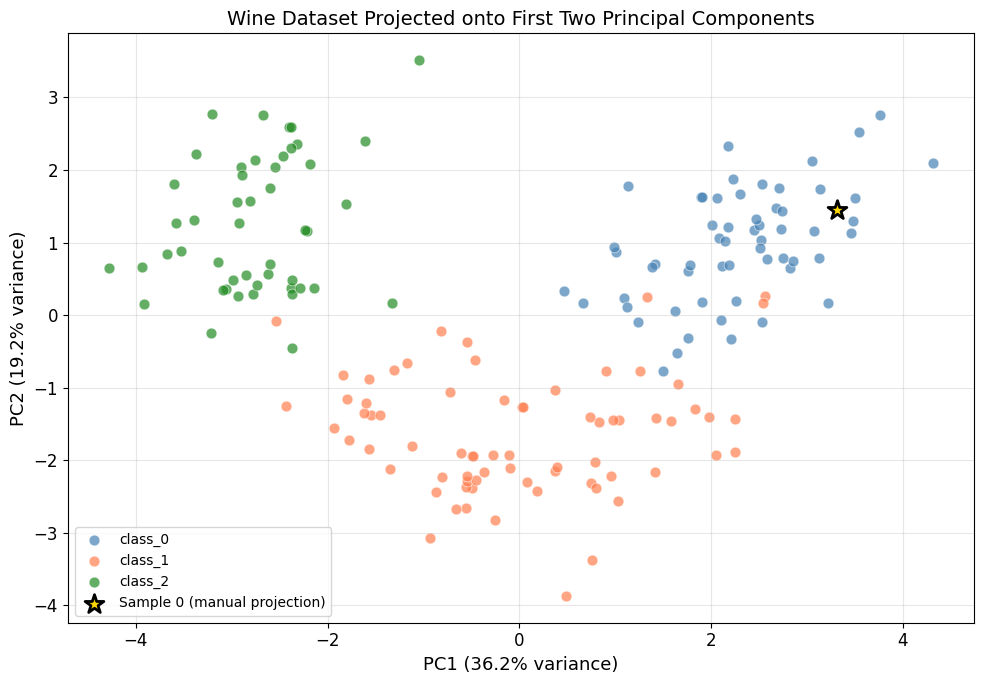

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

class_colors = ['steelblue', 'coral', 'forestgreen']
for c in range(3):
    mask = y_wine == c
    ax.scatter(X_wine_pca[mask, 0], X_wine_pca[mask, 1],
               c=class_colors[c], s=60, alpha=0.7,
               edgecolors='white', linewidth=0.5,
               label=wine.target_names[c])

# Highlight the sample we projected manually
ax.scatter(X_wine_pca[sample_idx, 0], X_wine_pca[sample_idx, 1],
           c='gold', s=200, marker='*', edgecolors='black',
           linewidth=2, zorder=5, label=f'Sample {sample_idx} (manual projection)')

ax.set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%} variance)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%} variance)', fontsize=13)
ax.set_title('Wine Dataset Projected onto First Two Principal Components', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key takeaways:**
- Each principal component is a weighted sum of original features (the loadings)
- The loadings tell you what each component "means" in domain terms
- `pca.transform()` is just a dot product: feature values × loadings
- PCA is unsupervised, but maximum-variance directions often align with meaningful structure
- Always standardize before PCA, and fit on training data only